In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import QuartileTransformer
df=pd.read_csv("drawndata1.csv")
df.head(10)

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a
5,180.095699,289.569088,a
6,254.567182,288.434128,a
7,283.587488,305.608829,a
8,133.750000,311.215526,a
9,429.660811,265.006662,a


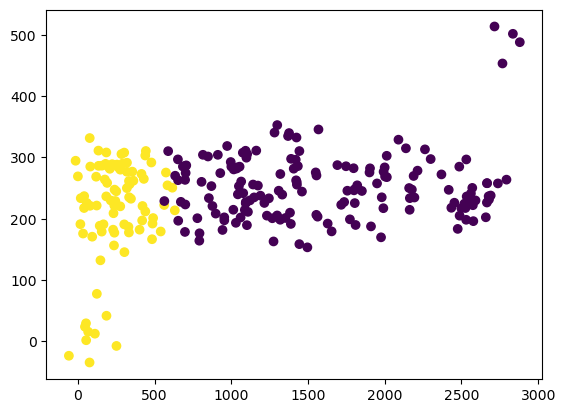

In [30]:
X=df[['x','y']].values
y=df['z']=="a"
# this creates a boolean series true or false like that which will 
# be perfect for colouring points
plt.scatter(X[:,0],X[:,1],c=y)
# c=y means colors points based on whether class is 'a'


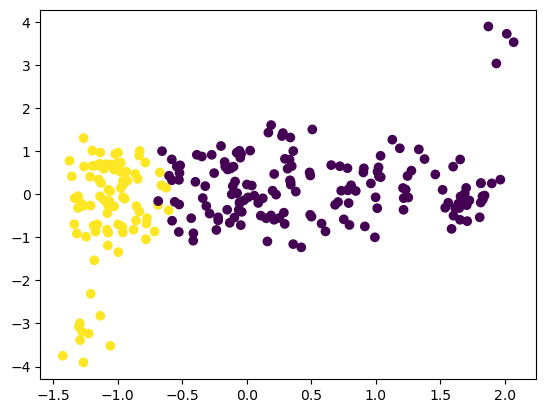

In [32]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline 
# with standard scaler
X_new = StandardScaler().fit_transform(X)
plt.scatter(X_new[:, 0], X_new[:, 1], c=y);

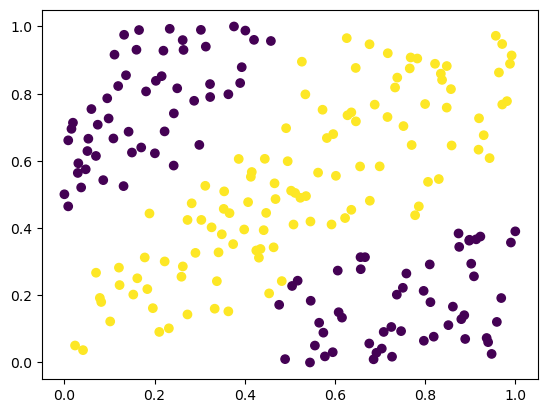

In [36]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline 
# with Quantiletransformer 
X_new = QuantileTransformer(n_quantiles=100).fit_transform(X)
plt.scatter(X_new[:, 0], X_new[:, 1], c=y);

In [34]:
# then compare to the standard scaler the  qurtile scaler scaled better 
# because there r less number of outliers and the the range on x and y axus same 0 to1
# but on the standard scaler we have outliers and the values on the axis r also different

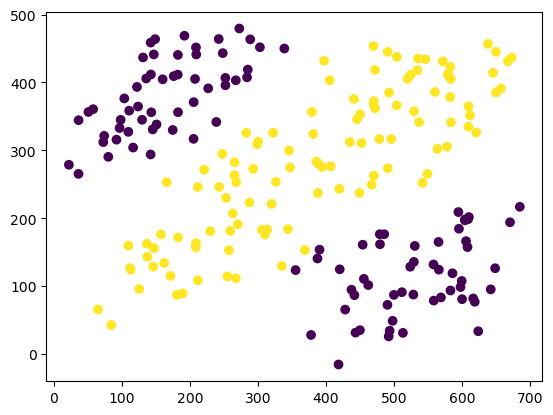

In [38]:
df=pd.read_csv("drawndata2.csv")
X=df[['x','y']].values
y=df['z']=='a'
plt.scatter(X[:,0],X[:,1],c=y)


In [40]:
from sklearn.linear_model import LogisticRegression
pipe=Pipeline([
    ("scale",QuantileTransformer(n_quantiles=100)),
    ("model",LogisticRegression())
])
pipe.fit(X,y)

,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_quantiles,100
,output_distribution,'uniform'
,ignore_implicit_zeros,False
,subsample,10000
,random_state,None
,copy,True
,penalty,'l2'


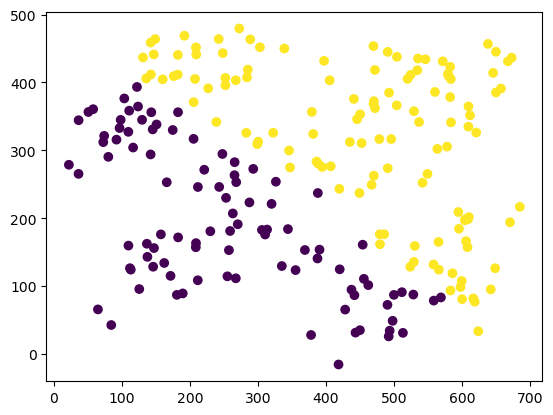

In [44]:
pred=pipe.predict(X)
plt.scatter(X[:,0],X[:,1],c=pred)

In [45]:
# lets change the pipeline from linear means x1 and x2 to non linear by adding x1*x2
# and x1^2 and x2^2
from sklearn.preprocessing import PolynomialFeatures
pipe=Pipeline([
    ("scale",PolynomialFeatures()),
    ("model",LogisticRegression())
])
pipe.fit(X,y)

,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,penalty,'l2'
,dual,False
,tol,0.0001


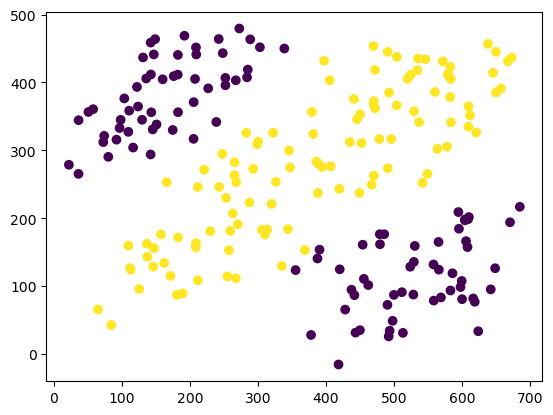

In [46]:
pred=pipe.predict(X)
plt.scatter(X[:,0],X[:,1],c=pred)

In [47]:
# based on preprocessing step the output depends choose wisely
# we cando preprocessing on categorical data too
arr=np.array(["low","low","high","medium"]).reshape(-1,1)
arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [48]:
from sklearn.preprocessing import OneHotEncoder
enc=OneHotEncoder()
enc.fit_transform(arr)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 3)>

In [52]:
enc=OneHotEncoder(sparse_output=False)
enc.fit_transform(arr)
# low with 0,1,0 and high is 1,0,0 and medium is 0,0,1

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [54]:
enc.transform([["zero"]])
#  this zero is never seen before it is telling an error  so let us add hanndle erroe


ValueError: Found unknown categories ['zero'] in column 0 during transform

In [57]:
enc=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
enc.fit_transform(arr)
enc.transform([["zero"]])

array([[0., 0., 0.]])